In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Load data
df = pd.read_excel(r"C:\Users\bhara\Documents\Airlink project\MLRData.xlsx")

# Target Variable - 1: Accepted if cost > 0, 0: Rejected if cost = 0
df['Accepted'] = (df['Cost'] > 0).astype(int)

#Aircraft Type encoded into 0,1,2 based on aircraft type
df_model = pd.get_dummies(df, columns=['Aircraft_Type'], drop_first=True)

#Feature variables
feature_cols = ['AW', 'Distance'] + [c for c in df_model.columns if 'Aircraft_Type_' in c]
X = df_model[feature_cols]
y = df_model['Accepted']

#Model training
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

#Calculated betas
beta_0 = model.intercept_[0]
betas = dict(zip(feature_cols, model.coef_[0]))

print("--- MODEL PARAMETERS (BETAS) ---")
print(f"Intercept (Beta_0): {beta_0:.4f}")
for feature, value in betas.items():
    print(f"Weight for {feature}: {value:.6f}")

#Probability
def predict_acceptance(aw, distance, aircraft_type):
    z = beta_0
    z += betas['AW'] * aw
    z += betas['Distance'] * distance
    dummy_col = f'Aircraft_Type_{aircraft_type}'
    if dummy_col in betas:
        z += betas[dummy_col]
    
    #convert raw numbers to probabilities
    probability = 1 / (1 + np.exp(-z))
    return probability

#Add train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model
model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

#Accuracy
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("Model Performance")
print(classification_report(y_test, y_pred))

#Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

#Sample values test
p = predict_acceptance(aw=2500, distance=500, aircraft_type='Widebody')
print(f"\nCalculated Acceptance Probability: {p:.2%}")

--- MODEL PARAMETERS (BETAS) ---
Intercept (Beta_0): 0.0000
Weight for AW: -0.000013
Weight for Distance: 0.000267
Weight for Aircraft_Type_Narrowbody: 0.000000
Weight for Aircraft_Type_Widebody: 0.000000
Overall Accuracy: 81.48%
Model Performance
              precision    recall  f1-score   support

           0       1.00      0.17      0.29        24
           1       0.81      1.00      0.89        84

    accuracy                           0.81       108
   macro avg       0.90      0.58      0.59       108
weighted avg       0.85      0.81      0.76       108

Confusion Matrix
[[ 4 20]
 [ 0 84]]

Calculated Acceptance Probability: 52.54%


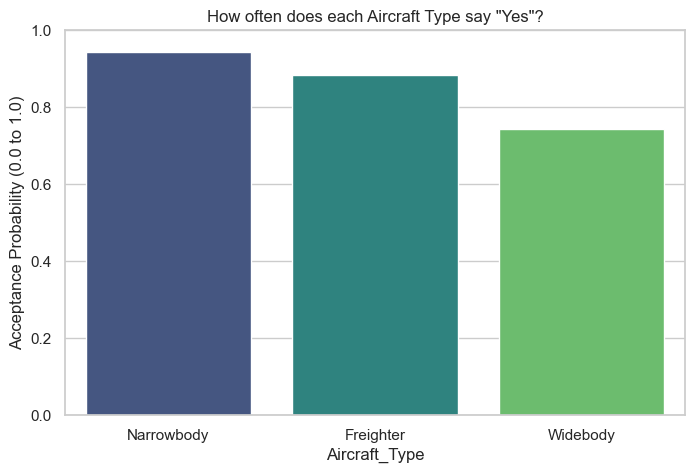

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#Acceptance rate vs aircraft type
plt.figure(figsize=(8, 5))
acc_rate = df.groupby('Aircraft_Type')['Accepted'].mean().sort_values(ascending=False)
sns.barplot(x=acc_rate.index, y=acc_rate.values, palette='viridis')
plt.title('How often does each Aircraft Type say "Yes"?')
plt.ylabel('Acceptance Probability (0.0 to 1.0)')
plt.ylim(0, 1)
plt.show()

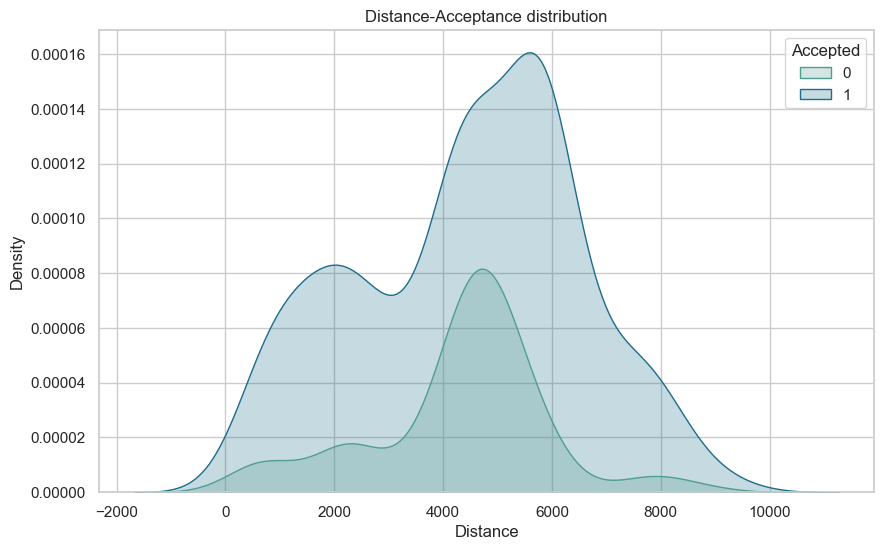

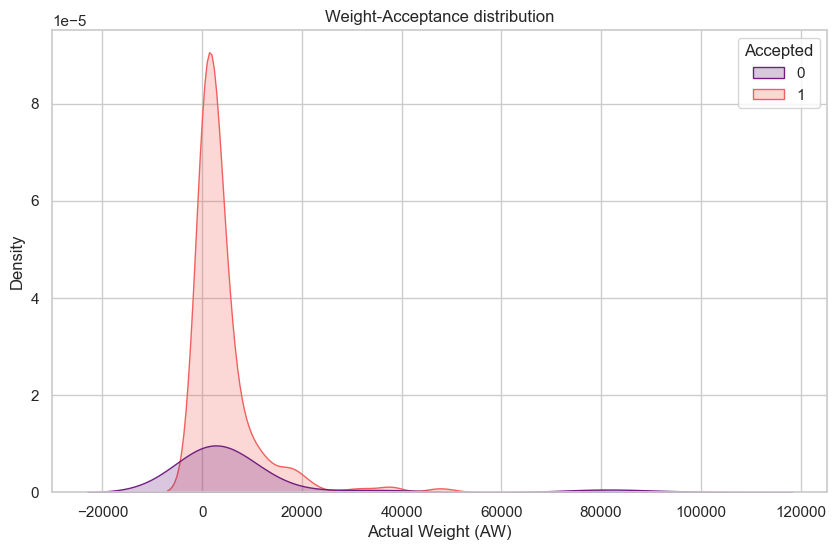

In [22]:
#Distance Distribution (Accepted vs Rejected)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Distance', hue='Accepted', fill=True, palette='crest')
plt.title('Distance-Acceptance distribution')
plt.xlabel('Distance')
plt.show()

#Weight Distribution (Accepted vs Rejected)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='AW', hue='Accepted', fill=True, palette='magma')
plt.title('Weight-Acceptance distribution')
plt.xlabel('Actual Weight (AW)')
plt.show()

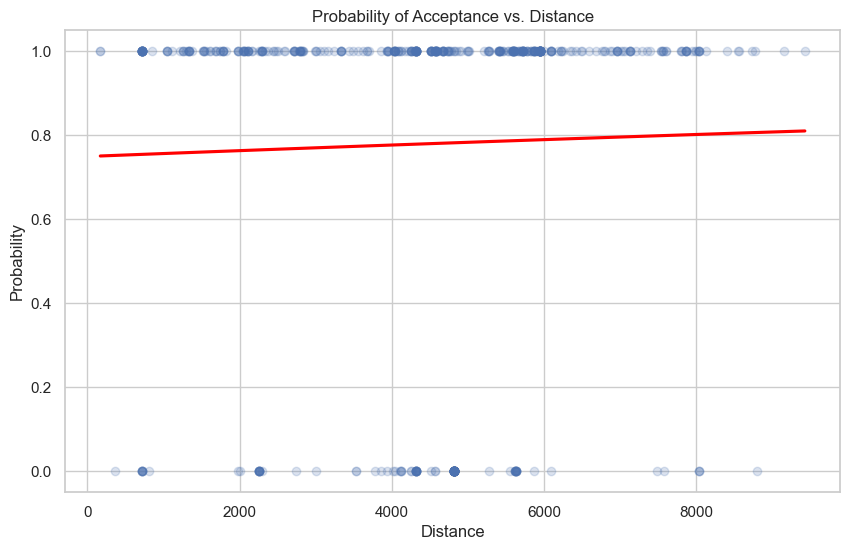

In [21]:
#Prbability of acceptance vs distance
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Distance', y='Accepted', logistic=True, ci=None, 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Probability of Acceptance vs. Distance')
plt.ylabel('Probability')
plt.show()